Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

Load your dataset (replace with actual file path)

In [ ]:
# Load dataset
df = pd.read_csv("/content/sunspots_data_1957-2022.csv", header=1, low_memory=False)

# Clean column names (remove accidental spaces)
df.columns = df.columns.str.strip()

# Parse dates (ISO format)
df["date"] = pd.to_datetime(df["date"], errors="coerce")


Filter by year

In [ ]:
# Filter by year (adjust if needed)
start_year = 1957
end_year = 2022
df = df[(df["date"].dt.year >= start_year) & (df["date"].dt.year <= end_year)]

# Convert important columns to numeric
df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["weighted spot count"] = pd.to_numeric(df["weighted spot count"], errors="coerce")


In [ ]:
# Clean column names
df.columns = df.columns.str.strip()

# Convert all possible latitude/longitude columns to numeric
for col in ["latitude", "longitude", "manual latitude", "manual longitude"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Create unified latitude/longitude columns
df["lat_final"] = df["latitude"].combine_first(df.get("manual latitude"))
df["lon_final"] = df["longitude"].combine_first(df.get("manual longitude"))

In [ ]:
df = df.dropna(subset=["date", "lat_final", "weighted spot count"])

Plot

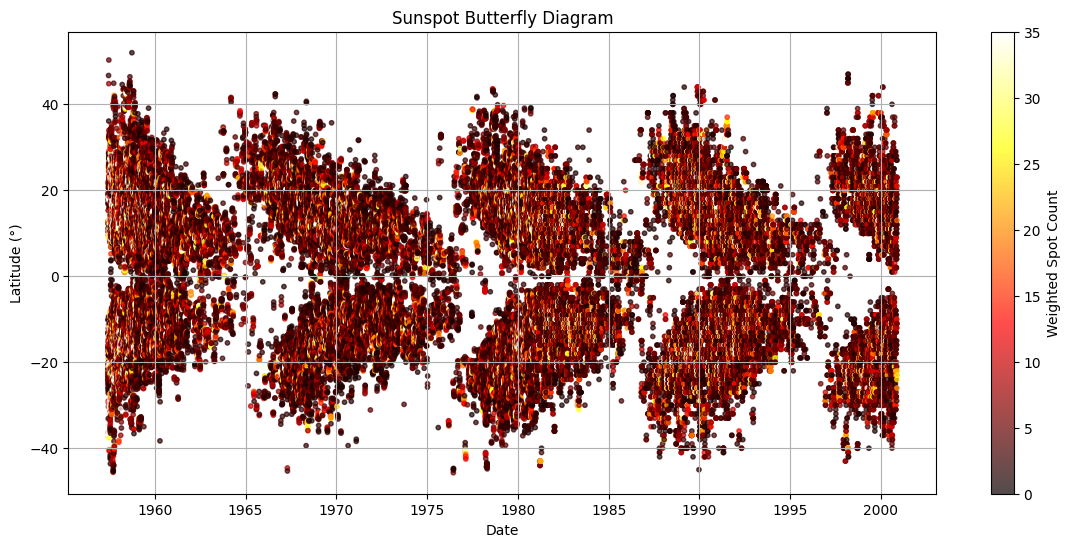

In [ ]:
vmax_val = df["weighted spot count"].quantile(0.95)
norm = colors.Normalize(vmin=0, vmax=vmax_val)

plt.figure(figsize=(14, 6))
sc = plt.scatter(
    df["date"],
    df["lat_final"],
    c=df["weighted spot count"],
    cmap="hot",
    s=10,
    alpha=0.7,
    norm=norm
)

plt.colorbar(sc, label="Weighted Spot Count")
plt.xlabel("Date")
plt.ylabel("Latitude (°)")
plt.title("Sunspot Butterfly Diagram")
plt.grid(True)
plt.show()